# Performance comparison
Here we walk through the necessary steps to reproduce the main figures of the performance comparison of different RBP datasets across cell lines using BRIDGE.

## 1. Load BRIDGE model and compute metrics
Please download the dataset from `Figshare`, unzip it, and place it in the expected directory (`BRIDGE/dataset/`). You also need to download the BRIDGE model and place it in the expected directory (`BRIDGE/model/`). Then run the code below to compute the BRIDGE metrics.

In [ ]:
%%bash
set -euo pipefail

ROOT_DIR="/home/wangyubo/code/BRIDGE"  # Change this to your own directory
cd "${ROOT_DIR}"
DATA_DIR="${ROOT_DIR}/dataset"
LOG="results/logs/validate_all.log"
mkdir -p results/logs

: > "$LOG"

for posfile in "$DATA_DIR"/*_pos.fa; do
  data_file="$(basename "$posfile")"
  data_file="${data_file%_pos.fa}"

  echo "Running validate for: ${data_file}" | tee -a "$LOG"

  python main.py \
    --validate \
    --data_path "$DATA_DIR" \
    --data_file "$data_file" \
    --device_num 0 \
    --Transformer_path ./RBPformer \
    --model_save_path ./results/model \
    2>&1 | tee -a "$LOG"
done


Running validate for: AARS_K562
/home/wangyubo/softwares/anaconda3/envs/BRIDGE/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertModel were not initialized from the model checkpoint at ./RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[INFO] Encoded 15000 sequences for AARS_K562, shape: (15000, 101, 99)
Valid motif file detected, skipping motif_prior: utils/motif_prior/output/AARS_K562/output/STRME_training_set.tab
AARS_K562 auc: 0.7972 acc: 0.7737 auprc: 0.7224 mcc: 0.4605
Running validat

In [ ]:
%%bash
set -euo pipefail

ROOT_DIR="/home/wangyubo/code/BRIDGE"  # Change this to your own directory
cd "${ROOT_DIR}"
LOG="results/logs/validate_all.log"
OUT="results/benchmarks/BRIDGE_auc.tsv"
mkdir -p results/benchmarks

echo -e "RBP_Cell\tBRIDGE" > "$OUT"

grep -E '^[A-Za-z0-9]+_[A-Za-z0-9]+ auc:' "$LOG" \
  | awk '{print $1 "\t" $3}' \
  >> "$OUT" || true

echo "Wrote: $OUT"
cat "$OUT"

Wrote: results/benchmarks/BRIDGE_auc.tsv
RBP_Cell	BRIDGE
AARS_K562	0.7972
AARS_K562	0.7972
AUH_HepG2	0.8979
AUH_HepG2	0.8979
AUH_K562	0.9265


## 2. Downstream analysis of cell type-specific BRIDGE results

### Cell-type-specific RBP binding performance
Next we will build a bubble scatter plot for **Matthews Correlation Coefficient (MCC)** across multiple cell lines and methods.

#### Load required packages

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

#### Load precomputed results for BRIDGE and other methods
```{note}
Running BRIDGE on the full dataset can take a long time. For convenience, we also provide the precomputed results for BRIDGE and all baseline methods on Figshare as `MCC.txt`, `ACC.txt`, and `AUC.txt`, which you can download directly.

You can modify `base_path` below to change where the data is stored.
```

In [4]:
# File path
TXT_PATH = "../cell_type_specific/MCC.txt"

# Bubble size range in scatter (area in points^2)
S_MIN = 50
S_MAX = 500

# Figure size
FIG_W = 14
FIG_H = 6

In [5]:
# Try TSV first, then fallback to whitespace-delimited
try:
    df = pd.read_csv(TXT_PATH, sep="\t")
    sep_used = "tab (TSV)"
except Exception:
    df = pd.read_csv(TXT_PATH, sep=r"\s+", engine="python")
    sep_used = "whitespace"

df.head()


,X,Cell_lines,Y,Values
0,0.5847,HEK293,aBRIDGE,0.5847
1,0.5653,HEK293T,aBRIDGE,0.5653
2,0.6473,Hela,aBRIDGE,0.6473
3,0.5582,HepG2,aBRIDGE,0.5582
4,0.6599,H9,aBRIDGE,0.6599


#### Convert data format
```{note}
We will validate columns and clean types:

1. Ensure the required columns exist
2. Convert `X` and `Values` to numeric
3. Drop any rows that cannot be parsed
```

In [6]:
required_cols = {"X", "Cell_lines", "Y", "Values"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(
        f"Missing columns: {missing}. Current columns: {list(df.columns)}. "
        f"If your file has no header, enable the header=None version in the previous cell."
    )

# Convert numeric columns
df["X"] = pd.to_numeric(df["X"], errors="coerce")
df["Values"] = pd.to_numeric(df["Values"], errors="coerce")

# Ensure text columns are strings
df["Cell_lines"] = df["Cell_lines"].astype(str)
df["Y"] = df["Y"].astype(str)

# Drop invalid rows
before = len(df)
df = df.dropna(subset=["X", "Values", "Cell_lines", "Y"])
after = len(df)

print("Dropped rows:", before - after)
print("Final shape:", df.shape)
print("Cell lines (unique):", sorted(df["Cell_lines"].unique().tolist()))
print("Values range:", (float(df["Values"].min()), float(df["Values"].max())))


Dropped rows: 0
Final shape: (48, 4)
Cell lines (unique): ['H9', 'HEK293', 'HEK293T', 'Hela', 'HepG2', 'K562']
Values range: (0.1089, 0.6599)


```{note}
We will create a clean method label:

1. Sort by the original `Y` to preserve method ordering
2. Remove the first character to make a clean label for display
```

In [7]:
df = df.sort_values("Y", ascending=False)
df["Method_Label"] = df["Y"].str[1:]

pairs = df[["Y", "Method_Label"]].drop_duplicates().reset_index(drop=True)


**Theme and palette**

This section sets the Seaborn theme and the exact color mapping.

There is also a small printout to flag any cell lines that appear in the data but not in the palette.


In [8]:
sns.set_theme(style="white", font_scale=1.2)
plt.rcParams["font.family"] = "sans-serif"

palette_dict = {
    "HEK293": "#3d405b",
    "HEK293T": "#81b29a",
    "Hela": "#f2cc8f",
    "HepG2": "#a8dadc",
    "H9": "#e07a5f",
    "K562": "#9E9AC8",
}

data_cells = set(df["Cell_lines"].unique().tolist())
palette_cells = set(palette_dict.keys())
missing_in_palette = sorted(list(data_cells - palette_cells))

print("Palette keys:", sorted(list(palette_cells)))
print("Data cell lines:", sorted(list(data_cells)))
print("Cell lines missing in palette:", missing_in_palette)


Palette keys: ['H9', 'HEK293', 'HEK293T', 'Hela', 'HepG2', 'K562']
Data cell lines: ['H9', 'HEK293', 'HEK293T', 'Hela', 'HepG2', 'K562']
Cell lines missing in palette: []


#### The plotting function

```{note}
Seaborn's default legend combines both color and size into one legend, which is not what we want.

So we will:

1. Remove the Seaborn legend
2. Create a dedicated legend for cell line colors
3. Create a dedicated legend for bubble sizes (min, mid, max)
4. Place them at the top of the figure
```

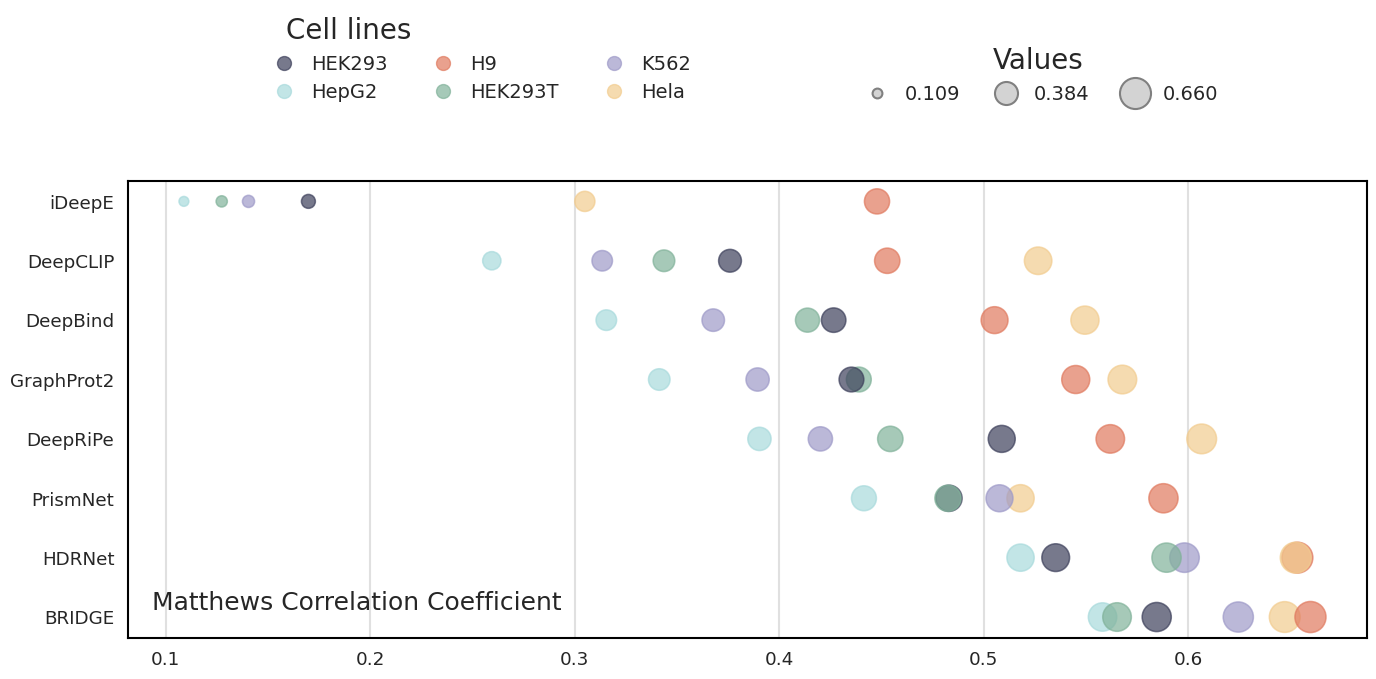

In [9]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

scatter = sns.scatterplot(
    data=df,
    x="X",
    y="Method_Label",
    hue="Cell_lines",
    size="Values",
    sizes=(S_MIN, S_MAX),
    alpha=0.7,
    palette=palette_dict,
    edgecolor=None,
    ax=ax,
)

# Axes labels off
ax.set_xlabel("")
ax.set_ylabel("")

# Vertical gridlines only
ax.xaxis.grid(True, color="#e0e0e0", linestyle="-", linewidth=1.5)
ax.yaxis.grid(False)

# Bottom-left annotation
ax.text(
    0.02, 0.05, "Matthews Correlation Coefficient",
    transform=ax.transAxes,
    fontsize=18, fontweight="medium",
    va="bottom", ha="left"
)

# Dark border
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color("black")

# Remove Seaborn legend
leg = ax.get_legend()
if leg is not None:
    leg.remove()

# --- Cell lines legend ---
cell_lines_order = ["HEK293", "HepG2", "H9", "HEK293T", "K562", "Hela"]
cell_handles = []
for cell in cell_lines_order:
    if cell not in df["Cell_lines"].unique():
        continue
    cell_handles.append(
        mlines.Line2D(
            [], [], color=palette_dict.get(cell, "gray"),
            marker="o", linestyle="None",
            markersize=10, label=cell, alpha=0.7
        )
    )

# --- Values legend (3 representative values) ---
vmin = float(df["Values"].min())
vmax = float(df["Values"].max())
size_values = np.array([vmin, (vmin + vmax) / 2, vmax])  # min / mid / max

def value_to_scatter_area(val, vmin=vmin, vmax=vmax, smin=S_MIN, smax=S_MAX):
    if vmax == vmin:
        return (smin + smax) / 2
    return smin + (val - vmin) / (vmax - vmin) * (smax - smin)

def area_to_markersize(area):
    # scatter uses area; Line2D uses diameter-like marker size
    return np.sqrt(area)

size_handles = []
for val in size_values:
    area = value_to_scatter_area(val)
    ms = area_to_markersize(area)
    size_handles.append(
        mlines.Line2D(
            [], [], color="lightgray", marker="o", linestyle="None",
            markersize=ms,
            label=f"{val:.3f}",
            markeredgecolor="gray", markeredgewidth=1.5
        )
    )

# Place legends
legend1 = fig.legend(
    handles=cell_handles,
    loc="upper center",
    bbox_to_anchor=(0.35, 1.15),
    ncol=3,
    frameon=False,
    columnspacing=2,
    handletextpad=0.5,
    title="Cell lines",
    title_fontsize=20,
)

try:
    legend1.get_title().set_position((-130, 0))
except Exception:
    pass

legend2 = fig.legend(
    handles=size_handles,
    loc="upper center",
    bbox_to_anchor=(0.75, 1.10),
    ncol=3,
    frameon=False,
    columnspacing=1.5,
    handletextpad=0.5,
    title="Values",
    title_fontsize=20,
)

plt.setp(legend1.get_texts(), fontsize=14)
plt.setp(legend2.get_texts(), fontsize=14)

plt.tight_layout()
plt.subplots_adjust(top=0.85)

plt.show()


#### Plot **AUC / ACC**

This cell loads two metric tables (`AUC.txt`, `ACC.txt`) and generates the same bubble plot for each.



=== AUC ===
shape: (48, 5)
cell lines: ['H9', 'HEK293', 'HEK293T', 'Hela', 'HepG2', 'K562']
values range: (0.6657, 0.9207)


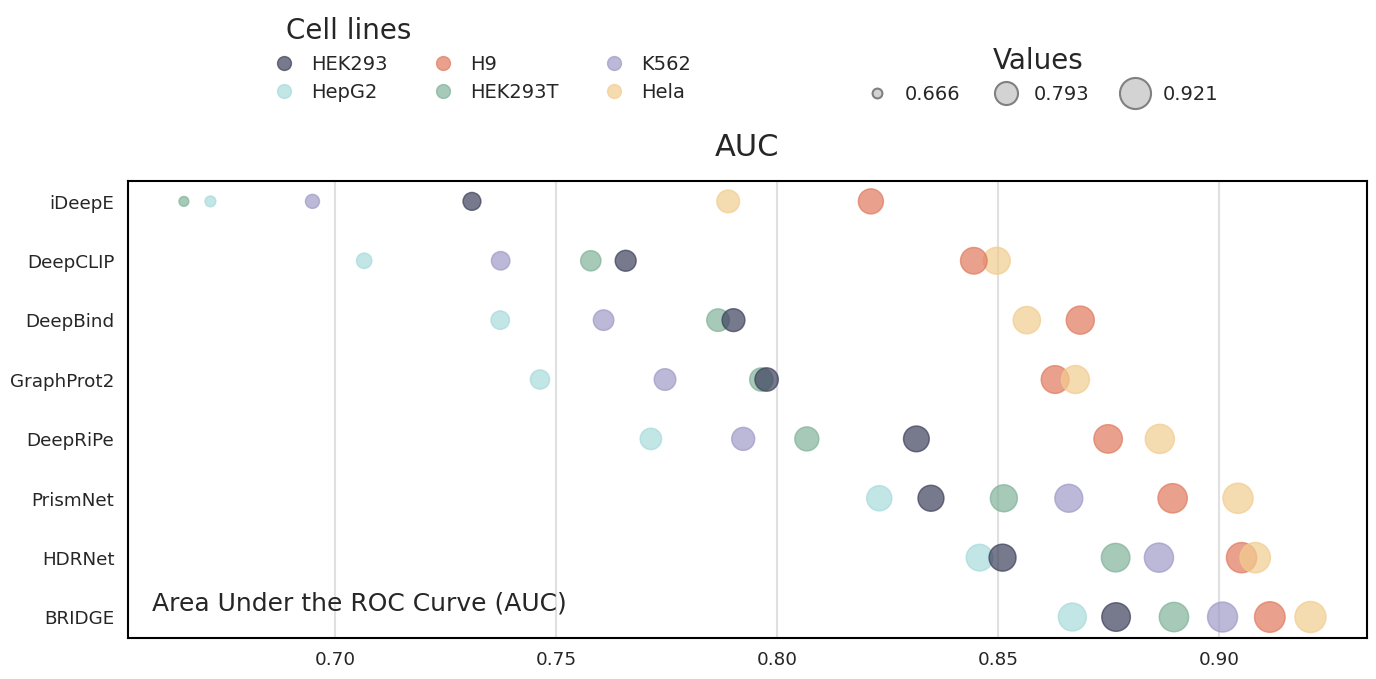


=== ACC ===
shape: (48, 5)
cell lines: ['H9', 'HEK293', 'HEK293T', 'Hela', 'HepG2', 'K562']
values range: (0.6844, 0.8512)


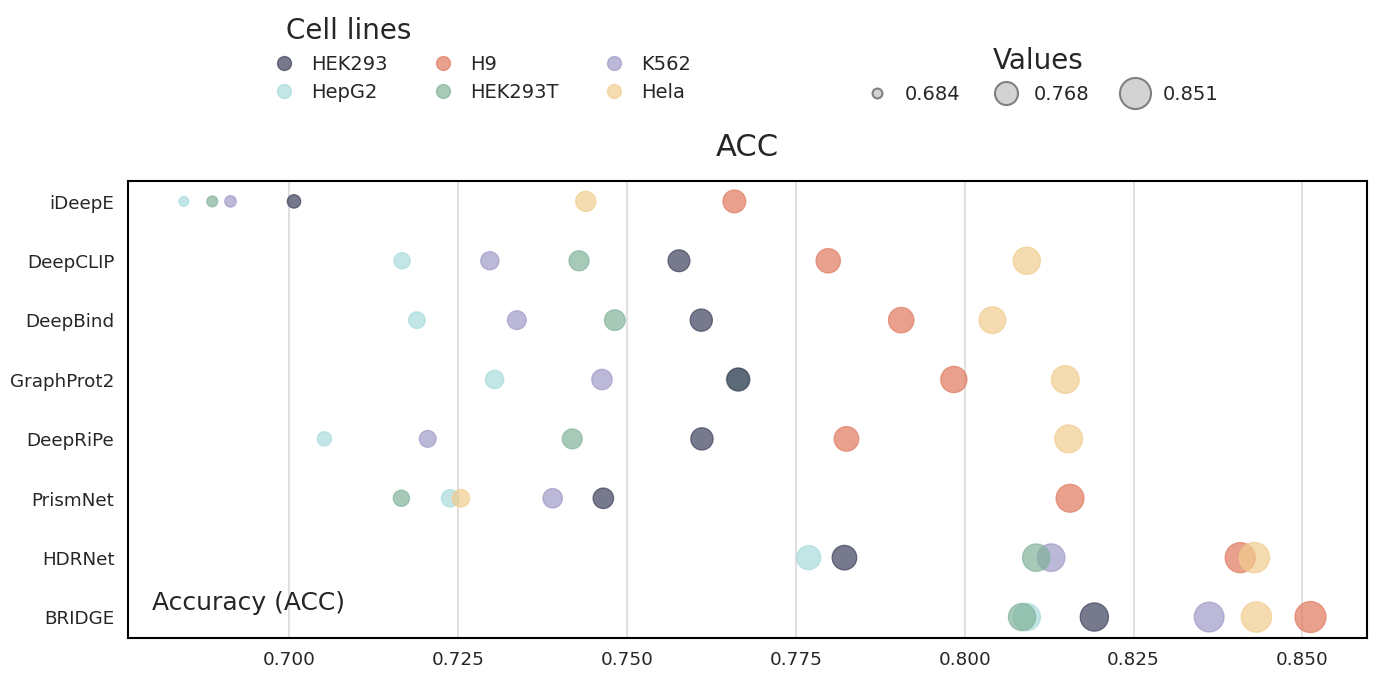

In [10]:
# --- Plot AUC / ACC / AUPRC (bubble scatter) ---
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ====== paths (edit if needed) ======
METRIC_DIR = "../../results/metrics"  # <-- change to your own path if different
METRIC_FILES = {
    "AUC": os.path.join(METRIC_DIR, "AUC.txt"),
    "ACC": os.path.join(METRIC_DIR, "ACC.txt"),
}

METRIC_LABEL = {
    "AUC": "Area Under the ROC Curve (AUC)",
    "ACC": "Accuracy (ACC)"
}

# ====== plot config ======
S_MIN = 50
S_MAX = 500
FIG_W = 14
FIG_H = 6

# Keep original palette (auto-extend if any cell line is missing)
BASE_PALETTE = {
    "HEK293": "#3d405b",
    "HEK293T": "#81b29a",
    "Hela": "#f2cc8f",
    "HepG2": "#a8dadc",
    "H9": "#e07a5f",
    "K562": "#9E9AC8",
}

CELL_LINES_ORDER = ["HEK293", "HepG2", "H9", "HEK293T", "K562", "Hela"]


def _read_table(txt_path: str) -> pd.DataFrame:
    """Try TSV first, then fallback to whitespace-delimited."""
    try:
        return pd.read_csv(txt_path, sep="\t")
    except Exception:
        return pd.read_csv(txt_path, sep=r"\s+", engine="python")


def _clean_df(df: pd.DataFrame) -> pd.DataFrame:
    required_cols = {"X", "Cell_lines", "Y", "Values"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(
            f"Missing columns: {missing}. Current columns: {list(df.columns)}. "
            "If your file has no header, use pd.read_csv(..., header=None) and set column names."
        )

    df = df.copy()
    df["X"] = pd.to_numeric(df["X"], errors="coerce")
    df["Values"] = pd.to_numeric(df["Values"], errors="coerce")
    df["Cell_lines"] = df["Cell_lines"].astype(str)
    df["Y"] = df["Y"].astype(str)
    df = df.dropna(subset=["X", "Values", "Cell_lines", "Y"])

    # Preserve method ordering by original Y, but show a clean label
    df = df.sort_values("Y", ascending=False)
    df["Method_Label"] = df["Y"].str[1:]
    return df


def _ensure_palette(df: pd.DataFrame, base_palette: dict) -> dict:
    palette = dict(base_palette)
    missing = sorted(set(df["Cell_lines"].unique()) - set(palette.keys()))
    if missing:
        extra_cols = sns.color_palette("tab20", n_colors=len(missing)).as_hex()
        for c, col in zip(missing, extra_cols):
            palette[c] = col
        print("[palette] Added colors for:", missing)
    return palette


def _value_to_scatter_area(val, vmin, vmax, smin=S_MIN, smax=S_MAX):
    if vmax == vmin:
        return (smin + smax) / 2
    return smin + (val - vmin) / (vmax - vmin) * (smax - smin)


def _area_to_markersize(area):
    # scatter uses area; Line2D uses diameter-like marker size
    return np.sqrt(area)


def plot_bubble(df: pd.DataFrame, metric_key: str, palette_dict: dict):
    sns.set_theme(style="white", font_scale=1.2)
    plt.rcParams["font.family"] = "sans-serif"

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    sns.scatterplot(
        data=df,
        x="X",
        y="Method_Label",
        hue="Cell_lines",
        size="Values",
        sizes=(S_MIN, S_MAX),
        alpha=0.7,
        palette=palette_dict,
        edgecolor=None,
        ax=ax,
    )

    # Axes labels off (match the existing style)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Vertical gridlines only
    ax.xaxis.grid(True, color="#e0e0e0", linestyle="-", linewidth=1.5)
    ax.yaxis.grid(False)

    # Bottom-left annotation (metric name)
    ax.text(
        0.02, 0.05, METRIC_LABEL.get(metric_key, metric_key),
        transform=ax.transAxes,
        fontsize=18, fontweight="medium",
        va="bottom", ha="left",
    )

    # Dark border
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("black")

    # Remove Seaborn legend
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    # --- Cell lines legend ---
    cell_handles = []
    for cell in CELL_LINES_ORDER:
        if cell not in df["Cell_lines"].unique():
            continue
        cell_handles.append(
            mlines.Line2D(
                [], [], color=palette_dict.get(cell, "gray"),
                marker="o", linestyle="None",
                markersize=10, label=cell, alpha=0.7
            )
        )

    # --- Values legend (min / mid / max) ---
    vmin = float(df["Values"].min())
    vmax = float(df["Values"].max())
    size_values = np.array([vmin, (vmin + vmax) / 2, vmax])

    size_handles = []
    for val in size_values:
        area = _value_to_scatter_area(val, vmin=vmin, vmax=vmax)
        ms = _area_to_markersize(area)
        size_handles.append(
            mlines.Line2D(
                [], [], color="lightgray", marker="o", linestyle="None",
                markersize=ms,
                label=f"{val:.3f}",
                markeredgecolor="gray", markeredgewidth=1.5
            )
        )

    # Place legends
    legend1 = fig.legend(
        handles=cell_handles,
        loc="upper center",
        bbox_to_anchor=(0.35, 1.15),
        ncol=3,
        frameon=False,
        columnspacing=2,
        handletextpad=0.5,
        title="Cell lines",
        title_fontsize=20,
    )
    try:
        legend1.get_title().set_position((-130, 0))
    except Exception:
        pass

    legend2 = fig.legend(
        handles=size_handles,
        loc="upper center",
        bbox_to_anchor=(0.75, 1.10),
        ncol=3,
        frameon=False,
        columnspacing=1.5,
        handletextpad=0.5,
        title="Values",
        title_fontsize=20,
    )

    plt.setp(legend1.get_texts(), fontsize=14)
    plt.setp(legend2.get_texts(), fontsize=14)

    # Optional: show the metric key as a small title
    ax.set_title(metric_key, fontsize=22, pad=18)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()


for metric_key, txt_path in METRIC_FILES.items():
    if not os.path.exists(txt_path):
        print(f"[skip] {metric_key}: file not found -> {txt_path}")
        continue

    df_metric = _read_table(txt_path)
    df_metric = _clean_df(df_metric)

    palette = _ensure_palette(df_metric, BASE_PALETTE)

    print(f"\n=== {metric_key} ===")
    print("shape:", df_metric.shape)
    print("cell lines:", sorted(df_metric["Cell_lines"].unique().tolist()))
    print("values range:", (float(df_metric["Values"].min()), float(df_metric["Values"].max())))

    plot_bubble(df_metric, metric_key, palette)
